<a href="https://colab.research.google.com/github/shanmithat/Hydrangea/blob/main/Hydrangea_Crowd_Trample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mediapipe

In [3]:
import mediapipe as mp
import cv2
import os
import numpy as np
from tqdm import tqdm

# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=False, model_complexity=1, min_detection_confidence=0.5)

# Your VisDrone frame folder
frame_dir = '/content/drive/MyDrive/VisDrone2020-CC/sequences/00001'
frames = sorted([f for f in os.listdir(frame_dir) if f.endswith('.jpg')])

keypoints_all_frames = []

for fname in tqdm(frames):
    frame = cv2.imread(os.path.join(frame_dir, fname))
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = pose.process(img_rgb)

    if results.pose_landmarks:
        kps = [[lm.x, lm.y] for lm in results.pose_landmarks.landmark[:18]]
    else:
        kps = [[0, 0]] * 18

    keypoints_all_frames.append(np.array(kps))

pose.close()


100%|██████████| 30/30 [00:43<00:00,  1.46s/it]


In [4]:
# Indices of overhead-visible keypoints (MediaPipe format)
overhead_indices = [0, 1, 2, 11, 12]

# Extract only selected keypoints
filtered_keypoints = []

for full_kp in keypoints_all_frames:
    subset = [full_kp[i] for i in overhead_indices]
    filtered_keypoints.append(np.array(subset))  # shape: (5, 2)

filtered_keypoints = np.array(filtered_keypoints)  # shape: (frames, 5, 2)
print(f"✅ Filtered keypoints shape: {filtered_keypoints.shape}")


✅ Filtered keypoints shape: (30, 5, 2)


In [5]:
# Calculate centroid of each frame (mean position of selected keypoints)
centroids = filtered_keypoints.mean(axis=1)  # shape: (frames, 2)

# Calculate frame-to-frame Euclidean distance (speed)
speeds = np.linalg.norm(np.diff(centroids, axis=0), axis=1)
print(f"✅ Calculated {len(speeds)} frame-to-frame speeds.")


✅ Calculated 29 frame-to-frame speeds.


In [6]:
def classify_speeds(speeds, threshold=0.005):
    return ['walking' if s > threshold else 'standing' for s in speeds]

labels = classify_speeds(speeds)

# Show summary
from collections import Counter
print("✅ Action label counts:", Counter(labels))


✅ Action label counts: Counter({'standing': 29})


In [7]:
import cv2
import os

# Path to your frame directory again
frame_dir = '/content/drive/MyDrive/VisDrone2020-CC/sequences/00001'
annotated_video_path = 'annotated_output.avi'
fps = 25

# Reload frame list
frames = sorted([f for f in os.listdir(frame_dir) if f.endswith('.jpg')])
frame_sample = cv2.imread(os.path.join(frame_dir, frames[0]))
height, width, _ = frame_sample.shape

# Initialize video writer
out = cv2.VideoWriter(annotated_video_path, cv2.VideoWriter_fourcc(*'XVID'), fps, (width, height))

# Loop through frames and annotate
for i in range(len(labels)):
    frame = cv2.imread(os.path.join(frame_dir, frames[i]))
    label = labels[i]
    color = (0, 255, 0) if label == 'walking' else (0, 0, 255)
    cv2.putText(frame, f"{label.upper()}", (30, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
    out.write(frame)

# Write final frame if speeds were one less
if len(frames) > len(labels):
    frame = cv2.imread(os.path.join(frame_dir, frames[-1]))
    cv2.putText(frame, f"standing", (30, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    out.write(frame)

out.release()
print(f"✅ Annotated video saved as: {annotated_video_path}")


✅ Annotated video saved as: annotated_output.avi


In [8]:
import os
import cv2
import mediapipe as mp
import numpy as np
from tqdm import tqdm

# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=False, min_detection_confidence=0.5)

# Video folder paths
base_dir = '/content/drive/MyDrive/VisDrone2020-CC/sequences'
video_folders = ['00001', '00002']

# Store keypoints per folder
all_videos_keypoints = {}

for folder in video_folders:
    print(f"📂 Processing: {folder}")
    frame_dir = os.path.join(base_dir, folder)
    frame_files = sorted([f for f in os.listdir(frame_dir) if f.endswith('.jpg')])

    keypoints_frames = []

    for fname in tqdm(frame_files):
        frame_path = os.path.join(frame_dir, fname)
        frame = cv2.imread(frame_path)
        img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(img_rgb)

        if results.pose_landmarks:
            kps = [[lm.x, lm.y] for lm in results.pose_landmarks.landmark[:18]]
        else:
            kps = [[0, 0]] * 18

        keypoints_frames.append(np.array(kps))

    all_videos_keypoints[folder] = np.array(keypoints_frames)
    print(f"✅ Extracted keypoints from {len(keypoints_frames)} frames in {folder}")

pose.close()


📂 Processing: 00001


100%|██████████| 30/30 [00:02<00:00, 11.80it/s]


✅ Extracted keypoints from 30 frames in 00001
📂 Processing: 00002


100%|██████████| 30/30 [00:41<00:00,  1.37s/it]

✅ Extracted keypoints from 30 frames in 00002


In [9]:
# Indices of top-view visible keypoints
overhead_indices = [0, 1, 2, 11, 12]

# Store filtered keypoints
filtered_keypoints_dict = {}

for folder in all_videos_keypoints:
    keypoints = all_videos_keypoints[folder]
    filtered = []

    for frame_kps in keypoints:
        selected = [frame_kps[i] for i in overhead_indices]
        filtered.append(np.array(selected))  # shape (5, 2)

    filtered_keypoints_dict[folder] = np.array(filtered)  # shape (num_frames, 5, 2)

    print(f"✅ Filtered {folder}: {filtered_keypoints_dict[folder].shape}")


✅ Filtered 00001: (30, 5, 2)
✅ Filtered 00002: (30, 5, 2)


In [10]:
def compute_speeds(filtered_kps):
    centroids = filtered_kps.mean(axis=1)  # shape: (frames, 2)
    speeds = np.linalg.norm(np.diff(centroids, axis=0), axis=1)  # shape: (frames - 1,)
    return speeds


In [11]:
video_speeds = {}
for folder in filtered_keypoints_dict:
    video_speeds[folder] = compute_speeds(filtered_keypoints_dict[folder])
    print(f"✅ Speeds computed for {folder}: {len(video_speeds[folder])} values")


✅ Speeds computed for 00001: 29 values
✅ Speeds computed for 00002: 29 values


In [12]:
def classify_speeds(speeds, threshold=0.005):
    return ['walking' if s > threshold else 'standing' for s in speeds]

video_labels = {}
for folder in video_speeds:
    video_labels[folder] = classify_speeds(video_speeds[folder])
    from collections import Counter
    print(f"📊 {folder} label distribution:", Counter(video_labels[folder]))


📊 00001 label distribution: Counter({'standing': 29})
📊 00002 label distribution: Counter({'standing': 25, 'walking': 4})


In [13]:
import cv2
import os

base_frame_dir = '/content/drive/MyDrive/VisDrone2020-CC/sequences'

for folder in video_labels:
    print(f"🎥 Annotating {folder}")
    frame_dir = os.path.join(base_frame_dir, folder)
    frame_files = sorted([f for f in os.listdir(frame_dir) if f.endswith('.jpg')])

    # Read first frame to get dimensions
    sample = cv2.imread(os.path.join(frame_dir, frame_files[0]))
    height, width, _ = sample.shape

    # Video writer setup
    out_path = f'annotated_{folder}.avi'
    out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'XVID'), 25, (width, height))

    # Annotate each frame
    for i in range(len(video_labels[folder])):
        frame = cv2.imread(os.path.join(frame_dir, frame_files[i]))
        label = video_labels[folder][i]
        color = (0, 255, 0) if label == 'walking' else (0, 0, 255)
        cv2.putText(frame, label.upper(), (30, 30), cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 2)
        out.write(frame)

    # Final frame (optional if frame count > label count)
    if len(frame_files) > len(video_labels[folder]):
        last = cv2.imread(os.path.join(frame_dir, frame_files[-1]))
        cv2.putText(last, "STANDING", (30, 30), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 2)
        out.write(last)

    out.release()
    print(f"✅ Saved: {out_path}")


🎥 Annotating 00001
✅ Saved: annotated_00001.avi
🎥 Annotating 00002
✅ Saved: annotated_00002.avi


In [14]:
def detect_trampling_frame(speeds, threshold=3.0):
    # Moving average of prior speeds (for stability)
    moving_avg = []

    for i in range(len(speeds)):
        if i < 10:
            moving_avg.append(np.mean(speeds[:i+1]))
        else:
            moving_avg.append(np.mean(speeds[i-10:i]))

    # Detect when speed exceeds N× the prior average
    for i in range(1, len(speeds)):
        if moving_avg[i-1] > 0 and speeds[i] > threshold * moving_avg[i-1]:
            return i, speeds[i], moving_avg[i-1]

    return None, None, None


In [15]:
for folder in video_speeds:
    idx, peak, baseline = detect_trampling_frame(video_speeds[folder], threshold=3.0)
    if idx:
        print(f"🚨 Possible trampling origin in {folder} at frame {idx}")
        print(f"   ➤ Speed surged from avg {baseline:.5f} to {peak:.5f}")
    else:
        print(f"✅ No surge detected in {folder}")


✅ No surge detected in 00001
🚨 Possible trampling origin in 00002 at frame 8
   ➤ Speed surged from avg 0.07916 to 0.33261


In [16]:
import cv2
import os

# Assuming FPS = 25, update if needed
fps = 25

for folder in video_speeds:
    idx, peak, baseline = detect_trampling_frame(video_speeds[folder], threshold=3.0)
    if idx:
        print(f"\n🎯 Trampling surge detected in {folder} at frame {idx} (~{idx//fps} sec)")

        frame_dir = os.path.join(base_frame_dir, folder)
        frame_files = sorted([f for f in os.listdir(frame_dir) if f.endswith('.jpg')])

        frame_path = os.path.join(frame_dir, frame_files[idx])
        frame = cv2.imread(frame_path)

        # Annotate the frame
        label = f"TRAMPLING ORIGIN (Speed: {peak:.5f})"
        cv2.putText(frame, label, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2)

        out_name = f"trampling_frame_{folder}.jpg"
        cv2.imwrite(out_name, frame)
        print(f"✅ Saved potential trampling frame as: {out_name}")
    else:
        print(f"\n✅ No surge detected in {folder}")



✅ No surge detected in 00001

🎯 Trampling surge detected in 00002 at frame 8 (~0 sec)
✅ Saved potential trampling frame as: trampling_frame_00002.jpg


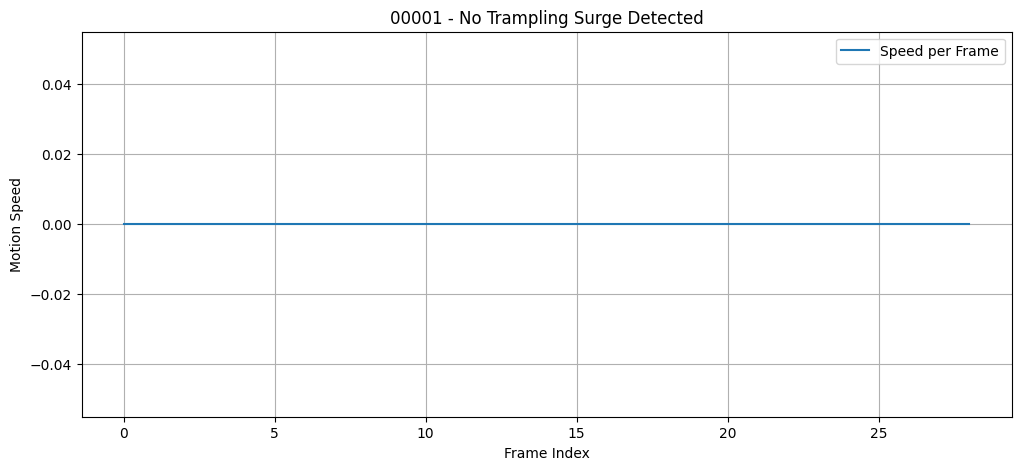

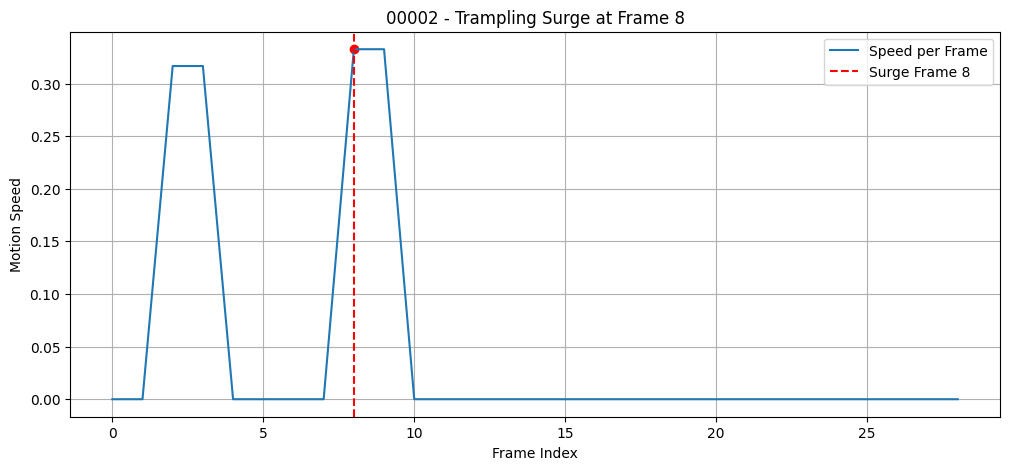

In [17]:
import matplotlib.pyplot as plt

for folder in video_speeds:
    speeds = video_speeds[folder]
    idx, peak, baseline = detect_trampling_frame(speeds, threshold=3.0)

    plt.figure(figsize=(12, 5))
    plt.plot(speeds, label='Speed per Frame')
    if idx:
        plt.axvline(x=idx, color='red', linestyle='--', label=f'Surge Frame {idx}')
        plt.scatter(idx, peak, color='red')
        plt.title(f"{folder} - Trampling Surge at Frame {idx}")
    else:
        plt.title(f"{folder} - No Trampling Surge Detected")

    plt.xlabel("Frame Index")
    plt.ylabel("Motion Speed")
    plt.legend()
    plt.grid(True)
    plt.show()


In [18]:
sequence_length = 10
pose_sequences = []
sequence_labels = []

for folder in filtered_keypoints_dict:
    keypoints = filtered_keypoints_dict[folder]
    speeds = video_speeds[folder]
    labels = video_labels[folder]

    for i in range(len(keypoints) - sequence_length):
        seq = keypoints[i:i+sequence_length]
        pose_sequences.append(seq)

        # Majority vote: if most of this sequence is walking → label as walking
        majority_label = labels[i:i+sequence_length].count('walking')
        sequence_labels.append(1 if majority_label > (sequence_length // 2) else 0)


In [19]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import numpy as np

# Convert to numpy arrays
X = np.array(pose_sequences).astype('float32')
y = to_categorical(np.array(sequence_labels), num_classes=2)

# Reshape to (samples, time, height, width, channels)
X = X.reshape(X.shape[0], sequence_length, 5, 2, 1)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ X shape: {X.shape}, y shape: {y.shape}")


✅ X shape: (40, 10, 5, 2, 1), y shape: (40, 2)


In [20]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, TimeDistributed, MaxPooling2D, Flatten
from tensorflow.keras.layers import LSTM, Dense, Dropout

input_shape = (sequence_length, 5, 2, 1)

inputs = Input(shape=input_shape)

# Time-distributed CNN block (shared across frames)
x = TimeDistributed(Conv2D(16, (2, 2), activation='relu'))(inputs)
x = TimeDistributed(MaxPooling2D(pool_size=(1, 1)))(x)
x = TimeDistributed(Flatten())(x)

# LSTM over sequence
x = LSTM(64, return_sequences=False)(x)
x = Dropout(0.4)(x)

# Output
outputs = Dense(2, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 5, 2, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 4, 1, 16)   │            80 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 4, 1, 16)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 64)         │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,234 (129.82 KB)

 Trainable params: 33,234 (129.82 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

callbacks = [EarlyStopping(patience=5, restore_best_weights=True)]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.8438 - loss: 0.6930 - val_accuracy: 1.0000 - val_loss: 0.6832
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.6845 - val_accuracy: 1.0000 - val_loss: 0.6735
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 1.0000 - loss: 0.6757 - val_accuracy: 1.0000 - val_loss: 0.6630
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 1.0000 - loss: 0.6650 - val_accuracy: 1.0000 - val_loss: 0.6516
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 1.0000 - loss: 0.6574 - val_accuracy: 1.0000 - val_loss: 0.6391
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 1.0000 - loss: 0.6435 - val_accuracy: 1.0000 - val_loss: 0.6251
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 1.0000 - loss: 0.6316 - val_accuracy: 1.0000 - val_loss: 0.6094
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 1.0000 - loss: 0.6150 - val_accuracy: 1.0000 - val_loss: 0.591

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Set label order and names
labels = [0, 1]  # 0 = standing, 1 = walking
target_names = ['standing', 'walking']

print("📊 Classification Report:\n")
print(classification_report(y_true, y_pred_classes, labels=labels, target_names=target_names))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
📊 Classification Report:

              precision    recall  f1-score   support

    standing       1.00      1.00      1.00         8
     walking       0.00      0.00      0.00         0

    accuracy                           1.00         8
   macro avg       0.50      0.50      0.50         8
weighted avg       1.00      1.00      1.00         8



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/me

MULTIPERSON DETECTION

In [24]:
!git clone https://github.com/abewley/sort.git
!pip install lap


Cloning into 'sort'...
remote: Enumerating objects: 208, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 208 (delta 45), reused 40 (delta 40), pack-reused 159 (from 1)
Receiving objects: 100% (208/208), 1.20 MiB | 2.91 MiB/s, done.
Resolving deltas: 100% (76/76), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 29.1 MB/s eta 0:00:00


In [25]:
def get_bbox_from_keypoints(landmarks, image_shape):
    """
    Estimate a bounding box from nose and shoulders.
    Returns: [x1, y1, x2, y2] (top-left to bottom-right)
    """
    h, w = image_shape[:2]

    try:
        nose = landmarks[0]
        l_shoulder = landmarks[11]
        r_shoulder = landmarks[12]

        xs = [nose.x, l_shoulder.x, r_shoulder.x]
        ys = [nose.y, l_shoulder.y, r_shoulder.y]

        # Convert normalized coords to pixels
        xs = [int(x * w) for x in xs]
        ys = [int(y * h) for y in ys]

        x1 = max(0, min(xs) - 10)
        y1 = max(0, min(ys) - 30)
        x2 = min(w, max(xs) + 10)
        y2 = min(h, max(ys) + 30)

        return [x1, y1, x2, y2]

    except:
        return None


In [1]:
# Clone YOLOv5
!git clone https://github.com/ultralytics/yolov5.git
%cd yolov5

# Install dependencies
!pip install -r requirements.txt


fatal: destination path 'yolov5' already exists and is not an empty directory.
/content/yolov5


In [36]:
!pip install filterpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=f9c0d117c0560fdd0a91c64b10bcd7d5692b9cee4f2c42e8342086ac86bc7449
  Stored in directory: /root/.cache/pip/wheels/12/dc/3c/e12983eac132d00f82a20c6cbe7b42ce6e96190ef8fa2d15e1
Successfully built filterpy


In [2]:
import torch
import cv2
import os
import numpy as np
from sort.sort import Sort  # Same SORT tracker as before
from tqdm import tqdm

# Load YOLOv5 model (you must be inside yolov5 folder)
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)
model.conf = 0.3  # confidence threshold
model.iou = 0.45
model.classes = [0]  # only detect 'person' class


/usr/local/lib/python3.11/dist-packages/torch/hub.py:330: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(
Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


YOLOv5 🚀 2025-8-2 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)

100%|██████████| 14.1M/14.1M [00:00<00:00, 115MB/s] 

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


In [3]:
# Paths
input_dir = '/content/drive/MyDrive/VisDrone2020-CC/sequences/00002'  # or video_0001/
output_path = '/content/yolov5_sort_output.avi'

frames = sorted([f for f in os.listdir(input_dir) if f.endswith('.jpg')])
sample = cv2.imread(os.path.join(input_dir, frames[0]))
height, width, _ = sample.shape

# SORT tracker
tracker = Sort()
out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'XVID'), 25, (width, height))

for fname in tqdm(frames):
    path = os.path.join(input_dir, fname)
    frame = cv2.imread(path)

    # Detect people
    results = model(frame)
    detections = []

    for *xyxy, conf, cls in results.xyxy[0].cpu().numpy():
        x1, y1, x2, y2 = map(int, xyxy)
        detections.append([x1, y1, x2, y2, float(conf)])

    detections = np.array(detections) if detections else np.empty((0, 5))
    tracks = tracker.update(detections)

    # Draw results
    for track in tracks:
        x1, y1, x2, y2, track_id = track.astype(int)
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame, f'ID: {track_id}', (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    out.write(frame)

out.release()
print(f"✅ Output saved as: {output_path}")


  0%|          | 0/30 [00:00<?, ?it/s]/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
  3%|▎         | 1/30 [00:00<00:10,  2.81it/s]/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
 10%|█         | 3/30 [00:00<00:03,  6.93it/s]/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
 

✅ Output saved as: /content/yolov5_sort_output.avi


PER PERSON ESTIMATION

In [5]:
# 🧠 Store past centroids for speed estimation
id_tracks = {}  # track_id: list of (frame_index, centroid_x, centroid_y)

for frame_idx, fname in enumerate(tqdm(frames)):
    ...
    tracks = tracker.update(detections)

    for track in tracks:
        x1, y1, x2, y2, track_id = track.astype(int)
        cx = (x1 + x2) // 2
        cy = (y1 + y2) // 2

        if track_id not in id_tracks:
            id_tracks[track_id] = []
        id_tracks[track_id].append((frame_idx, cx, cy))

        # Optional: draw ID
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame, f'ID: {track_id}', (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    out.write(frame)


100%|██████████| 30/30 [00:00<00:00, 11513.32it/s]


In [6]:
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np

id_speeds = defaultdict(list)

for track_id, points in id_tracks.items():
    for i in range(1, len(points)):
        _, x1, y1 = points[i-1]
        _, x2, y2 = points[i]
        dist = np.linalg.norm([x2 - x1, y2 - y1])  # Euclidean distance
        id_speeds[track_id].append(dist)

# Optional: plot speed graph
for tid, speeds in id_speeds.items():
    plt.plot(speeds, label=f'ID {tid}')
plt.xlabel("Frame Index")
plt.ylabel("Speed (pixels/frame)")
plt.title("Per-Person Motion Speeds")
plt.legend()
plt.grid(True)
plt.savefig("per_id_speed_plot.png")
print("✅ Saved: per_id_speed_plot.png")


✅ Saved: per_id_speed_plot.png


In [7]:
for tid, speeds in id_speeds.items():
    if max(speeds) > np.mean(speeds[:5]) * 5:  # crude surge detection
        print(f"🚨 Possible first mover: ID {tid} — Sudden speed spike")


In [8]:
import cv2
import os

surge_threshold_factor = 5  # How many times faster than baseline to be considered a surge
fps = 25  # Set correct FPS if known

surge_frames = {}

for tid, speeds in id_speeds.items():
    if len(speeds) < 5:
        continue  # Skip too short tracks

    baseline = np.mean(speeds[:5])
    peak = max(speeds)
    if peak > baseline * surge_threshold_factor:
        surge_idx = speeds.index(peak) + 1  # +1 because we started at i=1
        frame_number = id_tracks[tid][surge_idx][0]
        surge_frames[tid] = frame_number
        print(f"🚨 ID {tid} surge at frame {frame_number} (speed = {peak:.2f})")


In [9]:
# Save frame images
for tid, frame_number in surge_frames.items():
    frame_path = os.path.join(input_dir, frames[frame_number])
    frame = cv2.imread(frame_path)

    # Highlight bounding box if available
    last_centroid = id_tracks[tid][frame_number - 1][1:]
    cv2.putText(frame, f"Trampling Surge - ID {tid}", (30, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 3)
    cv2.circle(frame, last_centroid, 10, (0, 0, 255), -1)

    out_path = f"surge_frame_ID{tid}.jpg"
    cv2.imwrite(out_path, frame)
    print(f"✅ Saved surge frame for ID {tid} as {out_path}")
